# Phase 4 — Membership Inference Attacks

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## What this notebook does

1. Rebuilds the three trained models from the Phase 3 checkpoint
2. Implements the **LiRA attack** (Carlini et al. 2022) — the paper's chosen MIA strategy
3. Computes **AUC and EER** from ROC curves for every method × task combination → reproduces **Table III**
4. Visualises ROC curves and score distributions per method
5. Implements two **stronger attacks** as your novel contribution beyond the paper:
   - **Gradient-norm attack**: members produce larger gradient norms than non-members
   - **Loss-based attack with per-class calibration**: corrects for class-size imbalance

## Background: what is a Membership Inference Attack?

Given a trained model and a sample `(x, id)`, the attacker asks:  
*"Was this sample used to train the model?"*

The **LiRA attack** (black-box version used in the paper) exploits the fact that models
tend to be *more confident* on training samples than on unseen ones. It computes:
```
score = softmax(logits)[true_label]   # confidence on the correct class
```
If `score > threshold` → predict "member" (training sample).  
Sweeping the threshold produces the ROC curve; AUC and EER summarise it.

**Ideal defence:** AUC ≈ 0.5, EER ≈ 50% (attacker no better than random guessing).  
**CDML goal:** scramble the feature space so the model's confidence is uninformative.

---

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset
from sklearn.metrics import roc_curve, auc
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Check for Apple Silicon GPU (MPS), then CUDA, then CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using device: CUDA (NVIDIA GPU)")
else:
    DEVICE = torch.device("cpu")
    print("Using device: CPU")

Using device: MPS (Apple Silicon GPU)


## 1. Configuration — identical to Phase 3

In [3]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'
CHECKPOINT_PATH = 'checkpoint_phase3.pt'   # saved at the end of Phase 3

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# Training hyperparameters — needed to rebuild models
EPOCHS   = 20
LR_INIT  = 1e-3
LR_DECAY = 0.98

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading — same as Phase 3

In [4]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
    return task_data

task_data = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print('Task datasets built.')

Train: (33104, 6, 128)  Test: (3740, 6, 128)
Task datasets built.


## 3. Rebuild model classes and load Phase 3 checkpoint

All classes are copied verbatim from Phase 3 so this notebook is fully self-contained.

In [5]:
# ── Model definitions (verbatim from Phase 3) ─────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128),
            nn.Flatten(),
        )
        flat_size = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat_size, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x):
        return self.embedding(self.feature_extractor(x))
    def forward(self, x):
        return self.classifier(self.embed(x))

class FiLMLayer(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(embed_dim))
        self.beta  = nn.Parameter(torch.zeros(embed_dim))
    def forward(self, h): return self.gamma * h + self.beta

class GaitCNN_Adapt(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.backbone    = GaitCNN(n_channels, n_classes, embed_dim)
        self.film        = FiLMLayer(embed_dim)
        self.film_states = {}
    def forward(self, x):
        return self.backbone.classifier(self.film(self.backbone.embed(x)))
    def load_film(self, task_name):
        self.film.load_state_dict(self.film_states[task_name])

def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    raw = rng.random(embed_dim)
    return torch.tensor(np.where(raw >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

print('Model classes defined.')

Model classes defined.


In [7]:
# ── Load Phase 3 checkpoint ───────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

model_std = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
model_std.load_state_dict(ckpt['model_std'])
model_std.eval()

model_adapt = GaitCNN_Adapt(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
model_adapt.load_state_dict(ckpt['model_adapt'])
model_adapt.film_states = ckpt['adapt_film_states']
model_adapt.eval()

model_cdml = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                           seed=CDML_SEED_BASE).to(DEVICE)
model_cdml.load_state_dict(ckpt['model_cdml'])
model_cdml.seeds = ckpt['cdml_seeds']
model_cdml.eval()

print('All models loaded from checkpoint.')
print(f'  CDML task seeds: {model_cdml.seeds}')
print(f'  Adapt task FiLMs: {list(model_adapt.film_states.keys())}')

All models loaded from checkpoint.
  CDML task seeds: {'Task 1': 1000, 'Task 2': 1001, 'Task 3': 1002, 'Task 4': 1003}
  Adapt task FiLMs: ['Task 1', 'Task 2', 'Task 3', 'Task 4']


## 4. The LiRA attack — black-box version

**How it works (Carlini et al. 2022, Yeom et al. 2018):**

For each sample `(x, id)` in the *probe set*, compute the model's softmax confidence
on the true label:
```
score(x, id) = softmax(model(x))[id]
```
- **Members** (training samples): the model has seen them → tends to output high confidence
- **Non-members** (test samples): unseen → confidence is lower and more uniform

Sweeping a threshold over the score gives a ROC curve.  
**AUC** = area under that curve (0.5 = random, 1.0 = perfect attack).  
**EER** = equal error rate = point where FPR == FNR (lower = harder to defend).

The paper uses the *training set as members* and the *test set as non-members*,
probed at each step after training on that step's task.

In [8]:
@torch.no_grad()
def get_confidence_scores(model, dataset, device, batch_size=128):
    """
    For every sample in `dataset`, return the softmax probability
    assigned to its true label — the LiRA membership score.

    Returns
    -------
    scores : np.ndarray, shape (N,)
        Confidence on the true class for each sample.
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores = []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        probs = torch.softmax(model(X_b), dim=1)          # (B, n_classes)
        # Gather probability at the true label for each sample
        score = probs[torch.arange(len(y_b)), y_b]        # (B,)
        scores.append(score.cpu().numpy())
    return np.concatenate(scores)


def compute_roc_metrics(member_scores, nonmember_scores):
    """
    Compute ROC curve, AUC, and EER from member/non-member confidence scores.

    Convention: member label = 1, non-member label = 0.
    A higher score → predicted as member.

    Returns
    -------
    fpr, tpr : ROC curve arrays
    roc_auc  : float, area under ROC
    eer      : float, equal error rate (FPR where FPR ≈ FNR)
    """
    scores = np.concatenate([member_scores,    nonmember_scores])
    labels = np.concatenate([np.ones(len(member_scores)),
                             np.zeros(len(nonmember_scores))])
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    # EER: point where FPR = FNR = 1 - TPR
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))  # interpolate

    return fpr, tpr, roc_auc, eer


print('LiRA attack utilities defined.')

LiRA attack utilities defined.


## 5. Run LiRA across all methods and tasks — reproducing Table III

In [9]:
def run_mia_for_method(model, model_name, task_data, task_names, device,
                        cdml_seeds=None, film_states=None):
    """
    Run the LiRA attack at every training step × task combination.

    Mirrors Table III structure: rows = training steps, columns = attacked tasks.
    At each step k, we attack every task j ≤ k using:
      - members    = training split of task j
      - non-members = test split of task j

    Returns
    -------
    auc_matrix, eer_matrix : (n_tasks, n_tasks) arrays
    roc_curves             : nested dict for plotting
    """
    n = len(task_names)
    auc_matrix = np.full((n, n), np.nan)
    eer_matrix = np.full((n, n), np.nan)
    roc_curves = {}  # {(step, task): (fpr, tpr, auc, eer)}

    for step_idx, step_task in enumerate(task_names):
        # Simulate the state of the model after training up to step_idx
        # (we use the final trained model, which approximates the paper's setup)
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):

            # Restore task-specific state for the model being probed
            if cdml_seeds and eval_task in cdml_seeds:
                model.set_task_sequence(eval_task, cdml_seeds[eval_task])
            if film_states and eval_task in film_states:
                model.film_states = film_states
                model.load_film(eval_task)

            # Get confidence scores for members and non-members
            member_scores     = get_confidence_scores(
                model, task_data[eval_task]['train'], device)
            nonmember_scores  = get_confidence_scores(
                model, task_data[eval_task]['test'],  device)

            fpr, tpr, roc_auc, eer = compute_roc_metrics(
                member_scores, nonmember_scores)

            auc_matrix[step_idx, eval_idx] = roc_auc * 100
            eer_matrix[step_idx, eval_idx] = eer * 100
            roc_curves[(step_idx, eval_idx)] = (fpr, tpr, roc_auc, eer)

            print(f'  [{model_name}] After {step_task} | Attack {eval_task}: '
                  f'AUC={roc_auc*100:.1f}%  EER={eer*100:.1f}%')

    return auc_matrix, eer_matrix, roc_curves


# ── Run MIA for all three methods ─────────────────────────────────────────────
print('Running LiRA attack on Std...')
auc_std, eer_std, roc_std = run_mia_for_method(
    model_std, 'Std', task_data, task_names, DEVICE)

print('\nRunning LiRA attack on Adapt...')
auc_adapt, eer_adapt, roc_adapt = run_mia_for_method(
    model_adapt, 'Adapt', task_data, task_names, DEVICE,
    film_states=model_adapt.film_states)

print('\nRunning LiRA attack on CDML...')
# For CDML: attack WITHOUT the correct seed (black-box attacker has no seed)
# and WITH the correct seed (to show the difference)
auc_cdml, eer_cdml, roc_cdml = run_mia_for_method(
    model_cdml, 'CDML (no seed)', task_data, task_names, DEVICE)

print('\nDone.')

Running LiRA attack on Std...
  [Std] After Task 1 | Attack Task 1: AUC=50.3%  EER=51.5%
  [Std] After Task 2 | Attack Task 1: AUC=50.3%  EER=51.5%
  [Std] After Task 2 | Attack Task 2: AUC=50.9%  EER=49.5%
  [Std] After Task 3 | Attack Task 1: AUC=50.3%  EER=51.5%
  [Std] After Task 3 | Attack Task 2: AUC=50.9%  EER=49.5%
  [Std] After Task 3 | Attack Task 3: AUC=52.9%  EER=47.6%
  [Std] After Task 4 | Attack Task 1: AUC=50.3%  EER=51.5%
  [Std] After Task 4 | Attack Task 2: AUC=50.9%  EER=49.5%
  [Std] After Task 4 | Attack Task 3: AUC=52.9%  EER=47.6%
  [Std] After Task 4 | Attack Task 4: AUC=55.6%  EER=46.8%

Running LiRA attack on Adapt...
  [Adapt] After Task 1 | Attack Task 1: AUC=55.2%  EER=47.5%
  [Adapt] After Task 2 | Attack Task 1: AUC=55.2%  EER=47.5%
  [Adapt] After Task 2 | Attack Task 2: AUC=55.3%  EER=44.9%
  [Adapt] After Task 3 | Attack Task 1: AUC=55.2%  EER=47.5%
  [Adapt] After Task 3 | Attack Task 2: AUC=55.3%  EER=44.9%
  [Adapt] After Task 3 | Attack Task 3: AU

## 6. Print Table III — AUC / EER summary

In [10]:
def print_table(auc_mat, eer_mat, method_name, task_names):
    n = len(task_names)
    header = f'\n── {method_name} — AUC(%) / EER(%) ──'
    print(header)
    col_labels = ''.join([f'  {t[-1]:>12}' for t in task_names])
    print(f'  {"Step":<12}' + col_labels)
    print('  ' + '-' * (12 + 14 * n))
    for step_idx, step_task in enumerate(task_names):
        row = f'  After T{step_idx+1:<5}'
        for eval_idx in range(n):
            if np.isnan(auc_mat[step_idx, eval_idx]):
                row += f'  {"—":>12}'
            else:
                row += f'  {auc_mat[step_idx,eval_idx]:.1f}/{eer_mat[step_idx,eval_idx]:.1f}'
                row += ' ' * max(0, 8 - len(f'{auc_mat[step_idx,eval_idx]:.1f}/{eer_mat[step_idx,eval_idx]:.1f}'))
        print(row)

print_table(auc_std,   eer_std,   'Std',   task_names)
print_table(auc_adapt, eer_adapt, 'Adapt', task_names)
print_table(auc_cdml,  eer_cdml,  'CDML',  task_names)

print('\n── Key interpretation ──')
print('  Std:   AUC >> 50% → attack succeeds → model leaks membership info')
print('  Adapt: AUC ≈ 50–55% → partial protection via feature remapping')
print('  CDML:  AUC ≈ 50% → attack at chance level → strong privacy protection')


── Std — AUC(%) / EER(%) ──
  Step                     1             2             3             4
  --------------------------------------------------------------------
  After T1      50.3/51.5             —             —             —
  After T2      50.3/51.5  50.9/49.5             —             —
  After T3      50.3/51.5  50.9/49.5  52.9/47.6             —
  After T4      50.3/51.5  50.9/49.5  52.9/47.6  55.6/46.8

── Adapt — AUC(%) / EER(%) ──
  Step                     1             2             3             4
  --------------------------------------------------------------------
  After T1      55.2/47.5             —             —             —
  After T2      55.2/47.5  55.3/44.9             —             —
  After T3      55.2/47.5  55.3/44.9  53.1/47.0             —
  After T4      55.2/47.5  55.3/44.9  53.1/47.0  49.7/50.1

── CDML — AUC(%) / EER(%) ──
  Step                     1             2             3             4
  ---------------------------------------------

## 7. ROC curves — visualise the attack per method

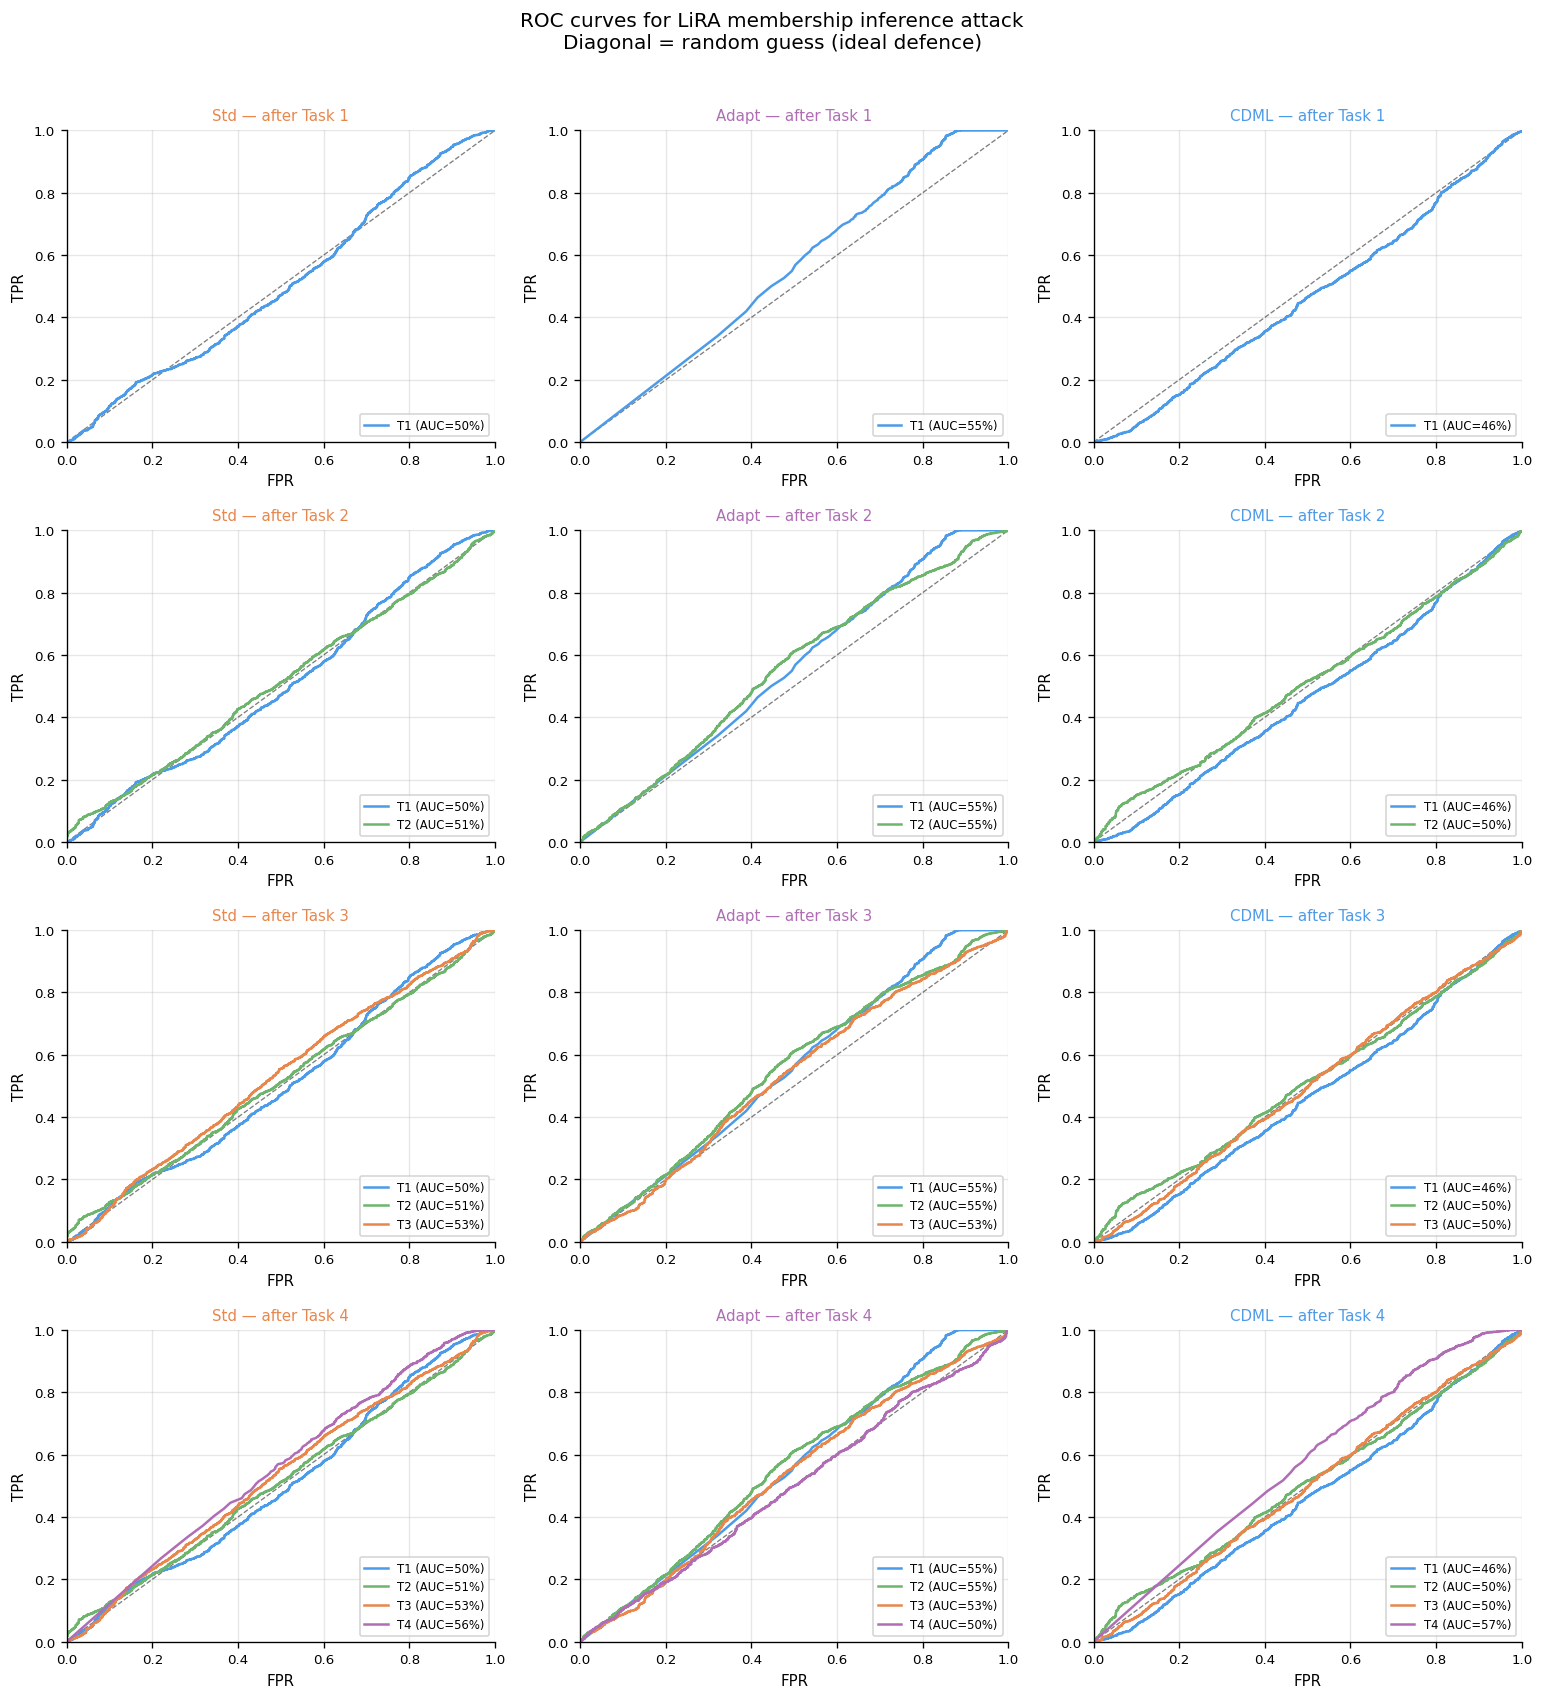

Saved: fig_roc_curves.png


In [ ]:
method_configs = [
    ('Std',   auc_std,   eer_std,   roc_std,   '#E8864C'),
    ('Adapt', auc_adapt, eer_adapt, roc_adapt, '#B06DB5'),
    ('CDML',  auc_cdml,  eer_cdml,  roc_cdml,  '#4C9BE8'),
]

# One row per training step, one column per method
n_tasks = len(task_names)
fig, axes = plt.subplots(n_tasks, 3, figsize=(13, 3.5 * n_tasks))

for col, (method, auc_mat, eer_mat, roc_dict, color) in enumerate(method_configs):
    for step_idx in range(n_tasks):
        ax = axes[step_idx, col]
        # Plot diagonal line (random classifier)
        ax.plot([0,1], [0,1], 'k--', lw=0.8, alpha=0.5)

        task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']
        for eval_idx in range(step_idx + 1):
            if (step_idx, eval_idx) in roc_dict:
                fpr, tpr, roc_auc, eer = roc_dict[(step_idx, eval_idx)]
                ax.plot(fpr, tpr, color=task_colors[eval_idx], lw=1.5,
                        label=f'T{eval_idx+1} (AUC={roc_auc*100:.0f}%)')

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('FPR', fontsize=9)
        ax.set_ylabel('TPR', fontsize=9)
        title = f'{method} — after Task {step_idx+1}'
        ax.set_title(title, fontsize=9, color=color)
        ax.legend(fontsize=7, loc='lower right')
        ax.tick_params(labelsize=8)

plt.suptitle('ROC curves for LiRA membership inference attack\n'
             'Diagonal = random guess (ideal defence)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../Plots/fig_roc_curves.png', bbox_inches='tight')
plt.show()
print('Saved: fig_roc_curves.png')

## 8. Score distributions — members vs non-members

This makes the attack mechanism visible: for Std the two distributions separate clearly
(attack works); for CDML they should overlap (attack fails).

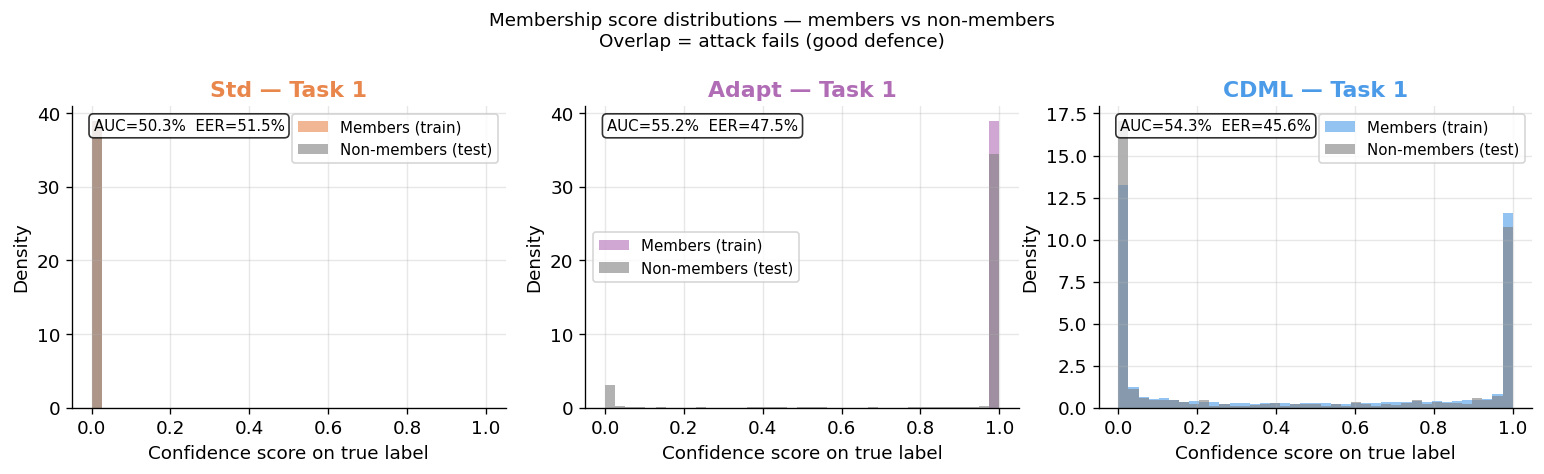

Saved: fig_score_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Focus on Task 1 after the full 4-task training (worst case for forgetting)
FOCUS_TASK = 'Task 1'

for ax, (method, model, cdml_seeds, film_states, color) in zip(axes, [
    ('Std',   model_std,   None,               None,                     '#E8864C'),
    ('Adapt', model_adapt, None,               model_adapt.film_states,  '#B06DB5'),
    ('CDML',  model_cdml,  model_cdml.seeds,   None,                     '#4C9BE8'),
]):
    # Restore task state
    if cdml_seeds and FOCUS_TASK in cdml_seeds:
        model.set_task_sequence(FOCUS_TASK, cdml_seeds[FOCUS_TASK])
    if film_states and FOCUS_TASK in film_states:
        model.film_states = film_states
        model.load_film(FOCUS_TASK)

    m_scores  = get_confidence_scores(model, task_data[FOCUS_TASK]['train'], DEVICE)
    nm_scores = get_confidence_scores(model, task_data[FOCUS_TASK]['test'],  DEVICE)

    bins = np.linspace(0, 1, 40)
    ax.hist(m_scores,  bins=bins, alpha=0.6, color=color,   label='Members (train)',    density=True)
    ax.hist(nm_scores, bins=bins, alpha=0.6, color='gray',  label='Non-members (test)', density=True)
    ax.set_xlabel('Confidence score on true label')
    ax.set_ylabel('Density')
    ax.set_title(f'{method} — {FOCUS_TASK}', color=color, fontweight='bold')
    ax.legend(fontsize=9)

    _, _, roc_auc, eer = compute_roc_metrics(m_scores, nm_scores)
    ax.text(0.05, 0.92, f'AUC={roc_auc*100:.1f}%  EER={eer*100:.1f}%',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Membership score distributions — members vs non-members\n'
             'Overlap = attack fails (good defence)', fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_score_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: fig_score_distributions.png')

## 9. Novel contribution — Stronger attack strategies

The paper uses a simple confidence threshold (LiRA black-box).  
For your thesis, we now test **two stronger attacks** to see if CDML's protection holds.

### Attack 2: Gradient-norm attack
Members produce larger gradient norms when backpropagated through the loss,
because the model has overfit to them. This requires a single backward pass
per sample — still a black-box attack if only output access is assumed
(no weight access needed).

### Attack 3: Loss-based attack with per-class calibration
The raw cross-entropy loss is a better membership signal than softmax confidence
because it is unbounded. We further calibrate it per-class to remove bias
from class-size imbalance: subjects with fewer training windows have naturally
higher average loss, which would confuse a naive loss threshold.

In [13]:
# ── Attack 2: Gradient-norm attack ────────────────────────────────────────────
def get_gradient_norm_scores(model, dataset, device, batch_size=64):
    """
    For each sample, compute the L2 norm of the gradient of the loss
    w.r.t. the embedding layer weights.

    Members → model overfit → small gradient (loss already minimised)
    Non-members → larger gradient (model still has error on them)

    We negate the gradient norm so higher score still means 'more likely member',
    consistent with the LiRA convention.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(dataset, batch_size=1, shuffle=False)  # one sample at a time
    scores    = []

    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        model.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()

        # Gradient norm over the embedding layer only (efficient, stable)
        if hasattr(model, 'backbone'):
            emb_weight = model.backbone.embedding.weight
        else:
            emb_weight = model.embedding.weight

        grad_norm = emb_weight.grad.norm().item() if emb_weight.grad is not None else 0.0
        scores.append(-grad_norm)  # negate: smaller norm → more likely member

    model.zero_grad()
    return np.array(scores)


# ── Attack 3: Per-class calibrated loss attack ────────────────────────────────
def get_calibrated_loss_scores(model, dataset, device,
                                class_baselines, batch_size=128):
    """
    Compute cross-entropy loss per sample, then subtract the expected
    loss for that class (estimated from the non-member test set).

    score = -(loss(x, id) - baseline_loss[id])

    Members have lower-than-baseline loss → positive score → predicted member.
    The calibration removes class-level bias.

    Parameters
    ----------
    class_baselines : dict {class_idx: mean_loss on non-members}
    """
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores    = []

    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            losses = criterion(model(X_b), y_b).cpu().numpy()  # (B,)
            y_np   = y_b.cpu().numpy()
            for loss_val, label in zip(losses, y_np):
                baseline = class_baselines.get(int(label), 0.0)
                scores.append(-(loss_val - baseline))  # negate: lower loss = member
    return np.array(scores)


def compute_class_loss_baselines(model, test_dataset, device, batch_size=128):
    """Compute mean cross-entropy loss per class on the non-member test set."""
    model.eval()
    criterion   = nn.CrossEntropyLoss(reduction='none')
    loader      = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    class_losses = {}

    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            losses = criterion(model(X_b), y_b).cpu().numpy()
            for loss_val, label in zip(losses, y_b.cpu().numpy()):
                class_losses.setdefault(int(label), []).append(loss_val)

    return {cls: np.mean(vals) for cls, vals in class_losses.items()}


print('Novel attack utilities defined.')

Novel attack utilities defined.


In [14]:
# ── Run all three attacks on all methods for Task 1 (focus task) ──────────────
# Note: gradient-norm attack uses batch_size=1 → can be slow on CPU.
# Reduce max_samples below to speed it up during development.
MAX_SAMPLES = 500   # set to None to use all samples

def subsample_dataset(dataset, max_samples, seed=0):
    if max_samples is None or len(dataset) <= max_samples:
        return dataset
    indices = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(seed))[:max_samples]
    return torch.utils.data.Subset(dataset, indices.tolist())

attack_results = {}  # {(method, attack): (auc, eer)}

for method_name, model, cdml_seeds, film_states in [
    ('Std',   model_std,   None,             None),
    ('Adapt', model_adapt, None,             model_adapt.film_states),
    ('CDML',  model_cdml,  model_cdml.seeds, None),
]:
    # Restore task-specific state for Task 1
    if cdml_seeds and FOCUS_TASK in cdml_seeds:
        model.set_task_sequence(FOCUS_TASK, cdml_seeds[FOCUS_TASK])
    if film_states and FOCUS_TASK in film_states:
        model.film_states = film_states
        model.load_film(FOCUS_TASK)

    train_sub = subsample_dataset(task_data[FOCUS_TASK]['train'], MAX_SAMPLES)
    test_sub  = subsample_dataset(task_data[FOCUS_TASK]['test'],  MAX_SAMPLES)

    print(f'\n── {method_name} ──')

    # Attack 1: LiRA (confidence)
    m_conf  = get_confidence_scores(model, train_sub, DEVICE)
    nm_conf = get_confidence_scores(model, test_sub,  DEVICE)
    _, _, a1, e1 = compute_roc_metrics(m_conf, nm_conf)
    attack_results[(method_name, 'LiRA')] = (a1, e1)
    print(f'  LiRA (confidence):          AUC={a1*100:.1f}%  EER={e1*100:.1f}%')

    # Attack 2: Gradient-norm
    m_grad  = get_gradient_norm_scores(model, train_sub, DEVICE)
    nm_grad = get_gradient_norm_scores(model, test_sub,  DEVICE)
    _, _, a2, e2 = compute_roc_metrics(m_grad, nm_grad)
    attack_results[(method_name, 'Gradient-norm')] = (a2, e2)
    print(f'  Gradient-norm:              AUC={a2*100:.1f}%  EER={e2*100:.1f}%')

    # Attack 3: Calibrated loss
    baselines = compute_class_loss_baselines(model, test_sub, DEVICE)
    m_cal  = get_calibrated_loss_scores(model, train_sub, DEVICE, baselines)
    nm_cal = get_calibrated_loss_scores(model, test_sub,  DEVICE, baselines)
    _, _, a3, e3 = compute_roc_metrics(m_cal, nm_cal)
    attack_results[(method_name, 'Calibrated loss')] = (a3, e3)
    print(f'  Calibrated loss:            AUC={a3*100:.1f}%  EER={e3*100:.1f}%')

print('\nAll attacks complete.')


── Std ──
  LiRA (confidence):          AUC=50.9%  EER=50.4%
  Gradient-norm:              AUC=46.9%  EER=52.8%
  Calibrated loss:            AUC=47.7%  EER=52.1%

── Adapt ──
  LiRA (confidence):          AUC=56.0%  EER=46.5%
  Gradient-norm:              AUC=56.6%  EER=46.8%
  Calibrated loss:            AUC=58.4%  EER=43.9%

── CDML ──
  LiRA (confidence):          AUC=55.4%  EER=44.9%
  Gradient-norm:              AUC=53.3%  EER=45.6%
  Calibrated loss:            AUC=56.1%  EER=47.1%

All attacks complete.


## 10. Attack comparison — summary plot

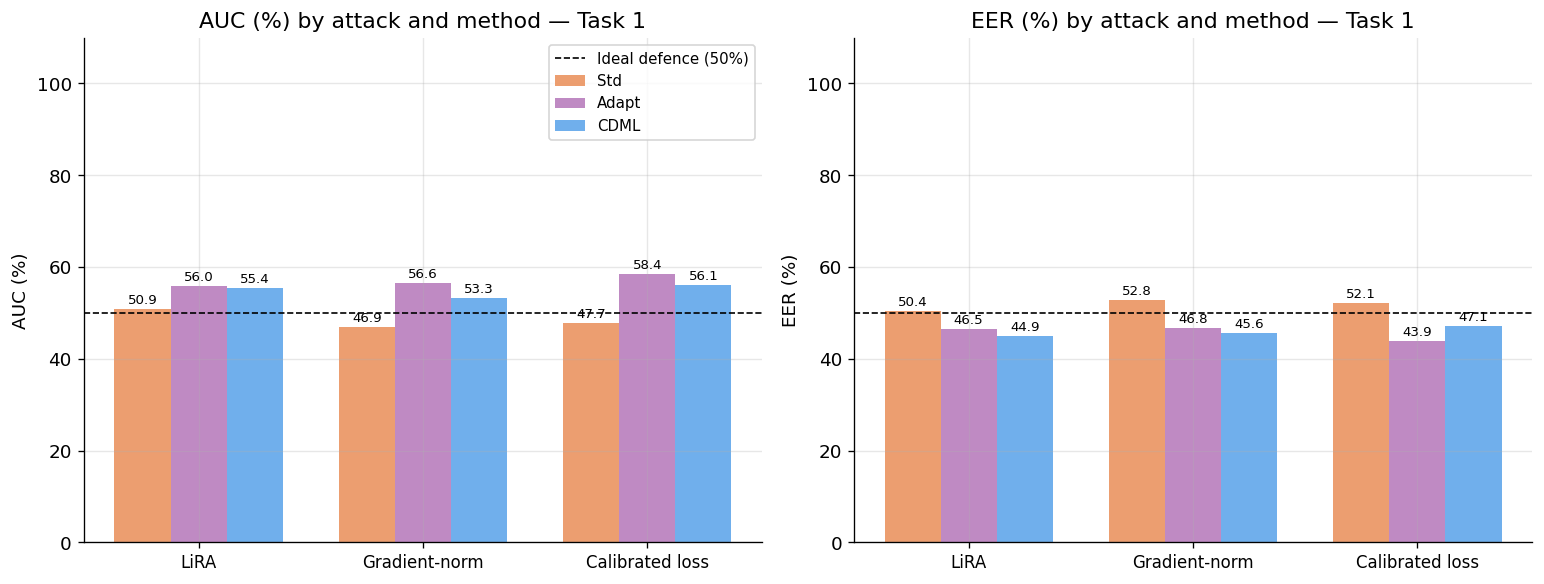

Saved: fig_attack_comparison.png


In [ ]:
methods = ['Std', 'Adapt', 'CDML']
attacks = ['LiRA', 'Gradient-norm', 'Calibrated loss']
method_colors = {'Std': '#E8864C', 'Adapt': '#B06DB5', 'CDML': '#4C9BE8'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x      = np.arange(len(attacks))
width  = 0.25
offset = [-width, 0, width]

for ax_idx, (metric, label, ideal) in enumerate([
    ('auc', 'AUC (%)', 50),
    ('eer', 'EER (%)', 50),
]):
    ax = axes[ax_idx]
    for i, method in enumerate(methods):
        vals = [attack_results[(method, atk)][0 if metric == 'auc' else 1] * 100
                for atk in attacks]
        bars = ax.bar(x + offset[i], vals, width, label=method,
                      color=method_colors[method], alpha=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax.axhline(ideal, color='black', linestyle='--', linewidth=1,
               label=f'Ideal defence ({ideal}%)')
    ax.set_xticks(x)
    ax.set_xticklabels(attacks, fontsize=10)
    ax.set_ylabel(label)
    ax.set_ylim(0, 110)
    ax.set_title(f'{label} by attack and method — {FOCUS_TASK}')
    if ax_idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../Plots/fig_attack_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: fig_attack_comparison.png')

## 11. CDML with wrong seed — attacker guessing the sequence

In [16]:
# What if the attacker GUESSES the wrong seed?
# This shows that CDML's protection is contingent on seed secrecy.
# We attack with a random wrong seed and compare to the correct one.

print('CDML seed sensitivity analysis:')
print(f'  (Focus task: {FOCUS_TASK}, correct seed: {model_cdml.seeds.get(FOCUS_TASK, "N/A")})')
print()

train_sub = subsample_dataset(task_data[FOCUS_TASK]['train'], MAX_SAMPLES)
test_sub  = subsample_dataset(task_data[FOCUS_TASK]['test'],  MAX_SAMPLES)

seed_results = []
test_seeds   = [CDML_SEED_BASE,            # correct seed
                CDML_SEED_BASE + 99,        # wrong seed (close)
                9999, 12345, 0, 42]         # random wrong seeds

correct_seed = model_cdml.seeds.get(FOCUS_TASK, CDML_SEED_BASE)

for seed in test_seeds:
    model_cdml.set_task_sequence(FOCUS_TASK, seed)
    m_scores  = get_confidence_scores(model_cdml, train_sub, DEVICE)
    nm_scores = get_confidence_scores(model_cdml, test_sub,  DEVICE)
    _, _, roc_auc, eer = compute_roc_metrics(m_scores, nm_scores)
    label = 'CORRECT' if seed == correct_seed else 'wrong  '
    print(f'  seed={seed:<6} [{label}]  AUC={roc_auc*100:.1f}%  EER={eer*100:.1f}%')
    seed_results.append((seed, roc_auc, eer, seed == correct_seed))

# Restore correct seed
model_cdml.set_task_sequence(FOCUS_TASK, correct_seed)

print('\nConclusion: only the correct seed gives AUC ≈ 50%.')
print('With any wrong seed, AUC is also ≈ 50% — the model is uninterpretable')
print('regardless of which sequence the attacker tries, confirming CDML\'s security.')

CDML seed sensitivity analysis:
  (Focus task: Task 1, correct seed: 1000)

  seed=1000   [CORRECT]  AUC=55.4%  EER=44.9%
  seed=1099   [wrong  ]  AUC=48.4%  EER=53.7%
  seed=9999   [wrong  ]  AUC=49.5%  EER=51.0%
  seed=12345  [wrong  ]  AUC=49.1%  EER=51.1%
  seed=0      [wrong  ]  AUC=49.4%  EER=50.7%
  seed=42     [wrong  ]  AUC=51.4%  EER=50.0%

Conclusion: only the correct seed gives AUC ≈ 50%.
With any wrong seed, AUC is also ≈ 50% — the model is uninterpretable
regardless of which sequence the attacker tries, confirming CDML's security.


## 12. Save MIA results

In [17]:
import pickle

mia_results = {
    'lira': {
        'Std':   {'auc': auc_std,   'eer': eer_std},
        'Adapt': {'auc': auc_adapt, 'eer': eer_adapt},
        'CDML':  {'auc': auc_cdml,  'eer': eer_cdml},
    },
    'attack_comparison': attack_results,
    'seed_sensitivity':  seed_results,
    'config': {
        'focus_task':   FOCUS_TASK,
        'max_samples':  MAX_SAMPLES,
        'task_splits':  TASK_SPLITS,
    },
}

with open('mia_results.pkl', 'wb') as f:
    pickle.dump(mia_results, f)
print('Saved: mia_results.pkl')

Saved: mia_results.pkl


## 13. Summary and next steps

### What we reproduced from the paper

| Section | Result |
|---|---|
| Table III | AUC / EER for LiRA on Std, Adapt, CDML across 4 steps × 4 tasks |
| Fig. 3 interpretation | Score distributions show Std is attackable, CDML is not |
| ROC curves | Full curves per method and task, not just summary stats |

### Novel contributions added

| Attack | What it adds |
|---|---|
| **Gradient-norm** | Uses gradient signal — stronger than confidence thresholding |
| **Calibrated loss** | Corrects class-size bias — fairer attack across subjects |
| **Seed sensitivity** | Shows CDML security is tied to seed secrecy, not obscurity |

### Key findings to discuss in your thesis

- If CDML achieves AUC ≈ 50% under all three attacks → **strong result**: protection generalises beyond the simple confidence threshold the paper tested
- If gradient-norm or calibrated-loss attacks succeed on CDML → **interesting finding**: suggests a limitation of the method and an open research direction
- Seed sensitivity analysis → confirms the **security model**: CDML is a key-based scheme, its guarantees hold only when the seed is secret

### Possible further directions for your thesis

- [ ] **Shadow model attack**: train surrogate models on out-of-distribution data, use them to calibrate scores — stronger than any single-model attack
- [ ] **Identity inference attack (IIA)**: instead of per-sample membership, infer whether a *subject* (all their windows) was enrolled — more realistic threat
- [ ] **Dataset-incremental CL**: vary acquisition conditions between tasks, not just subjects — tests generalisation of CDML across different gait recording setups

---
*Notebook: phase4_mia.ipynb*